In [1]:
import gc
import time
import gseapy as gp
import textwrap
import math

from pathlib import Path

import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/l

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
# Define Path #

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

In [4]:
## Read in DEG Lists at CellType Level ##

# by manuscript #
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [5]:
## Read in DEG Lists at Subtype Level ##

# by disease #
dge_22q11_st = pd.read_csv(CSV_PATH + "dreamlet_22q11_combined_subtype.csv")
dge_nrxn1_st = pd.read_csv(CSV_PATH + "dreamlet_nrxn1_combined_subtype.csv")
dge_idiopathic_st = pd.read_csv(CSV_PATH + "dreamlet_idiopathic_combined_subtype.csv")
dge_3q29_st = pd.read_csv(CSV_PATH + "dreamlet_purcell_dge_scz_results_subtype.csv")
dge_15q13_st = pd.read_csv(CSV_PATH + "dreamlet_walsh_15q13_dge_scz_results_subtype.csv")

In [6]:
## Calculate FDR at CellType Level ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

## Calculate FDR at Subtype Level ##

dge_nrxn1_st = fdr_per_celltype(dge_nrxn1_st)
dge_22q11_st = fdr_per_celltype(dge_22q11_st)
dge_idiopathic_st = fdr_per_celltype(dge_idiopathic_st)

# Merge Significance Def #

dge_3q29['significant_fdr'] = (dge_3q29['adj.P.Val'] < 0.05)
dge_15q13['significant_fdr'] = (dge_15q13['adj.P.Val'] < 0.05)

dge_3q29_st['significant_fdr'] = (dge_3q29_st['adj.P.Val'] < 0.05)
dge_15q13_st['significant_fdr'] = (dge_15q13_st['adj.P.Val'] < 0.05)

dge_3q29['estimate'] = dge_3q29['logFC'] 
dge_15q13['estimate'] = dge_15q13['logFC']

dge_3q29_st['estimate'] = dge_3q29_st['logFC'] 
dge_15q13_st['estimate'] = dge_15q13_st['logFC'] 

In [7]:
# Celltype #

all_celltypes = pd.concat([dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                dge_nrxn1.assign(group='NRXN1del'), 
                                dge_22q11.assign(group='22q11.2del'),
                                dge_3q29.assign(group='3q29.del'),
                                dge_15q13.assign(group='15q13del')], axis=0)

significant_all = all_celltypes[all_celltypes['significant_fdr']]

# Subtype #

all_subtypes = pd.concat([dge_idiopathic_st.assign(group='Idiopathic Schizophrenia'),
                            dge_nrxn1_st.assign(group='NRXN1del'), 
                            dge_22q11_st.assign(group='22q11.2del'),
                            dge_3q29_st.assign(group='3q29.del'),
                            dge_15q13_st.assign(group='15q13del')], axis=0)

significant_all_st = all_subtypes[all_subtypes['significant_fdr']]

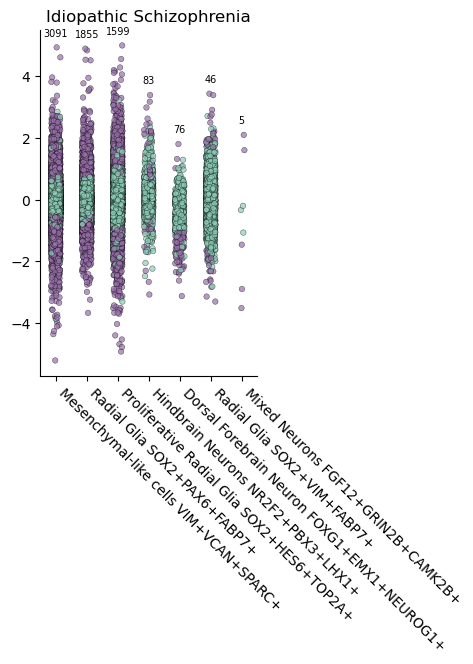

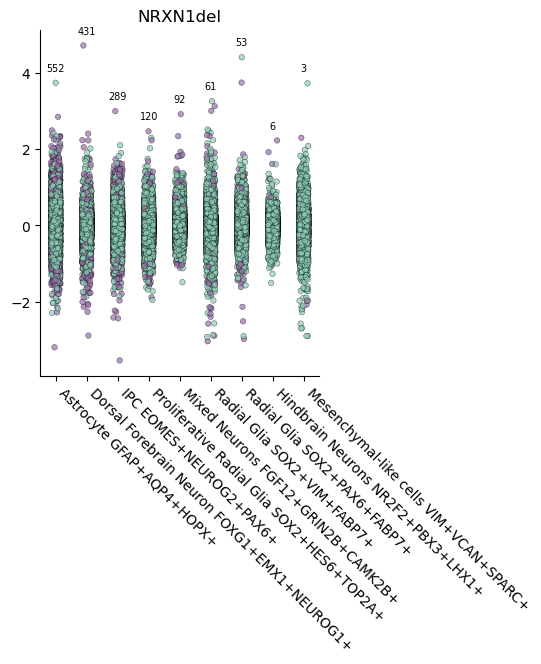

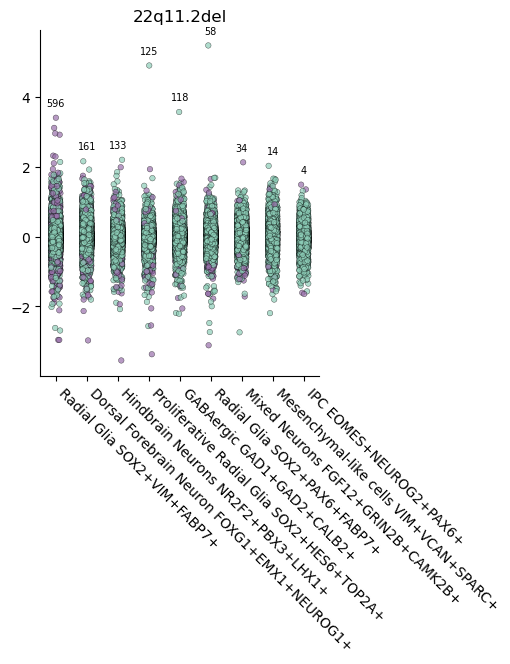

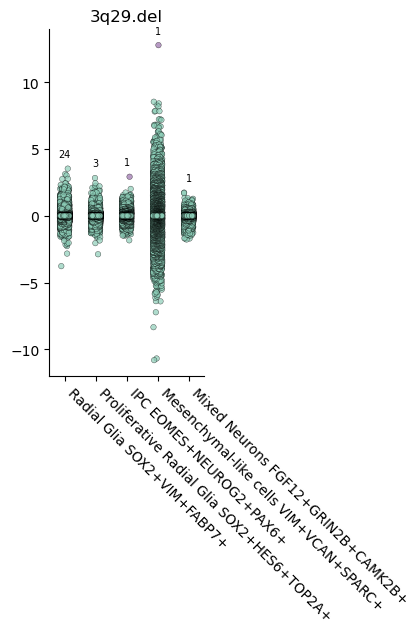

In [8]:
assay_order = sorted(all_celltypes["assay"].unique())

palette = dict(zip(assay_order, sns.color_palette("tab10", n_colors=len(assay_order))))

# ensure boolean dtype
all_celltypes["significant_fdr"] = all_celltypes["significant_fdr"].astype(bool)

sig_palette = {False: "#8dceb8ff", True: "#9970ab"}

hue_order = [False, True]

for disease in all_celltypes["group"].unique():

    temp_df = all_celltypes.loc[all_celltypes["group"] == disease].copy()

    significant_celltypes = (
        temp_df.groupby("assay")["significant_fdr"]
        .any()
        .loc[lambda s: s]
        .index
    )
    temp_df = temp_df[temp_df["assay"].isin(significant_celltypes)]

    if temp_df.shape[0] == 0:
        continue

    # Count significant hits per assay
    sig_counts = (
        temp_df[temp_df["significant_fdr"]]
        .groupby("assay")
        .size()
    )

    # Order assays from most to fewest significant hits (ties alphabetically)
    present_assays = (
        sig_counts.rename("n")
        .reset_index()
        .sort_values(["n", "assay"], ascending=[False, True])
        ["assay"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(len(present_assays) * 0.4, 4.5))

    sns.stripplot(
        data=temp_df,
        x="assay",
        y="estimate",
        order=present_assays,
        hue="significant_fdr",
        hue_order=hue_order,
        palette=sig_palette,
        jitter=0.15,
        size=4,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
    )

    # remove duplicate legends
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_title(disease)
    ax.set_xlabel("")
    ax.set_ylabel("")

    sns.despine()
    plt.xticks(rotation=-45, ha="left")

    # Save version WITHOUT labels
    plt.savefig(
        f"/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_{disease}_celltype_stripplot_without_labels.png",
        transparent=True,
        bbox_inches="tight",
        dpi=500,
    )

    # Add number of significant hits above each assay
    yrange = temp_df["estimate"].max() - temp_df["estimate"].min()

    for x, assay in enumerate(present_assays):
        y = temp_df.loc[temp_df["assay"] == assay, "estimate"].max()
        n = sig_counts.get(assay, 0)

        ax.text(
            x,
            y + 0.03 * yrange,
            str(n),
            ha="center",
            va="bottom",
            fontsize=7,
            color="black",
        )

    # Save version WITH labels
    plt.savefig(
        f"/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_{disease}_celltype_stripplot_with_labels.png",
        transparent=True,
        bbox_inches="tight",
        dpi=500,
    )

    plt.show()

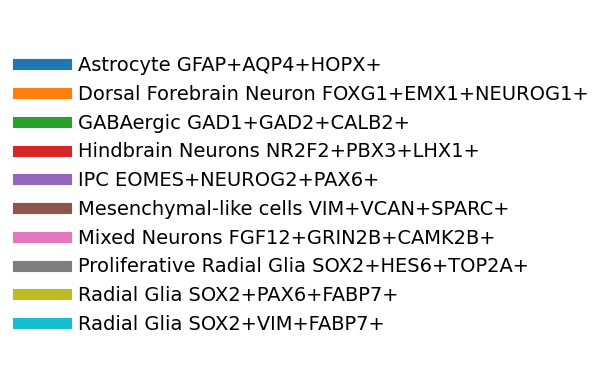

In [9]:
handles = [
    Line2D(
        [0], [0],
        color=palette[a],
        lw=8,
        label=a
    )
    for a in assay_order
]

ncols = 1  # six columns -> multiple rows automatically
nrows = math.ceil(len(handles) / ncols)

fig, ax = plt.subplots(figsize=(5, 0.4 * nrows))
ax.axis("off")

ax.legend(
    handles=handles,
    loc="center",
    ncol=ncols,
    frameon=False,
    fontsize=14,
    handlelength=2.5,
    handletextpad=0.6,
    columnspacing=2.0
)

plt.tight_layout()
plt.show()

In [10]:
all_subtypes['assay'] = all_subtypes['assay'].str.replace('CP-Primed RG TTR+FABP7+HOPX+', 'Choroid Plexus Primed RG TTR+FABP7+HOPX+')

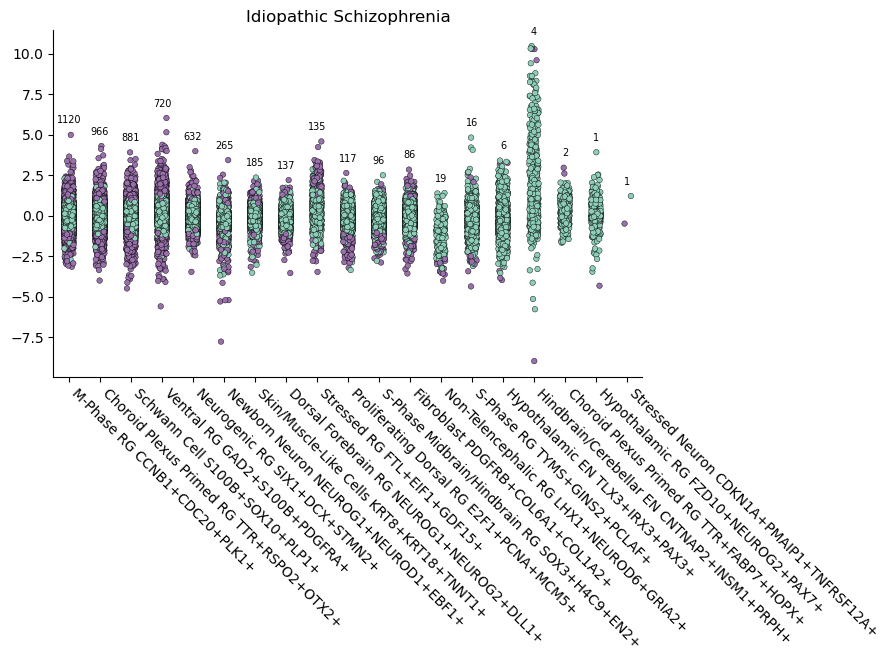

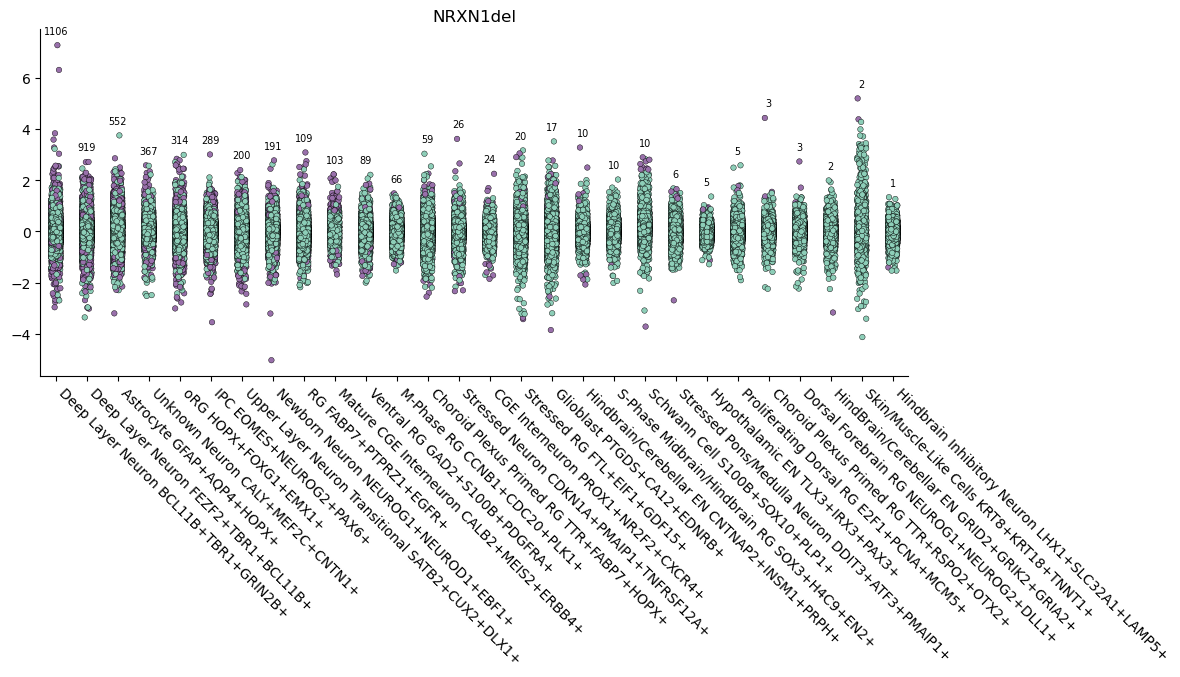

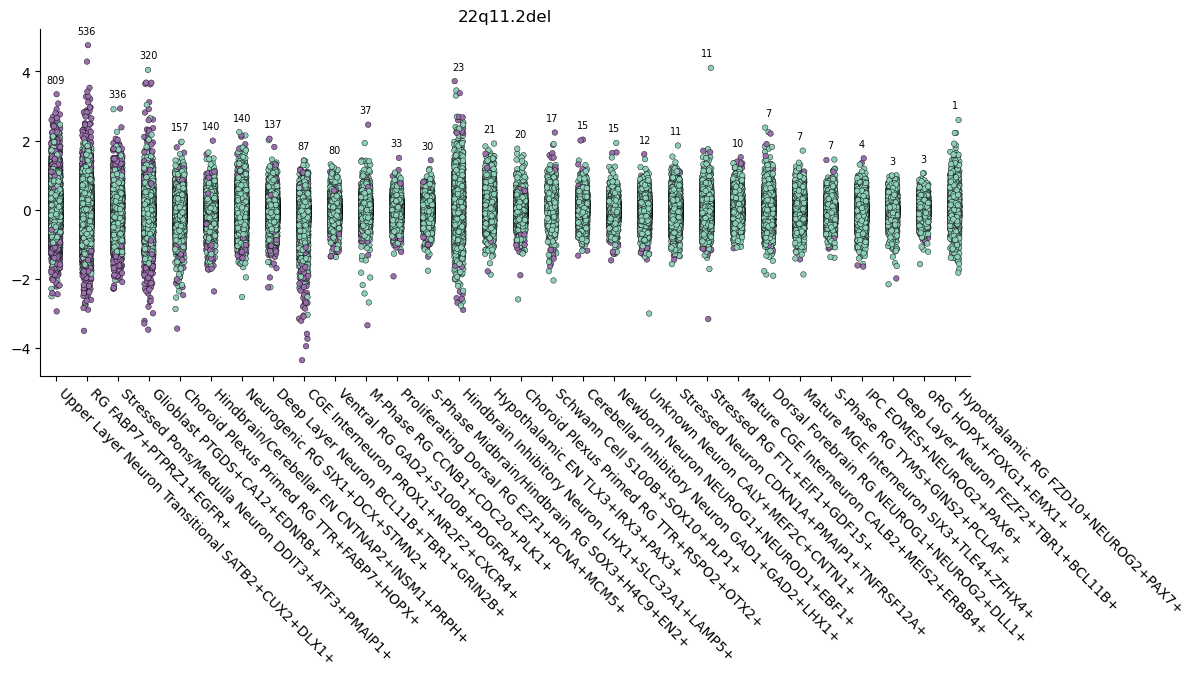

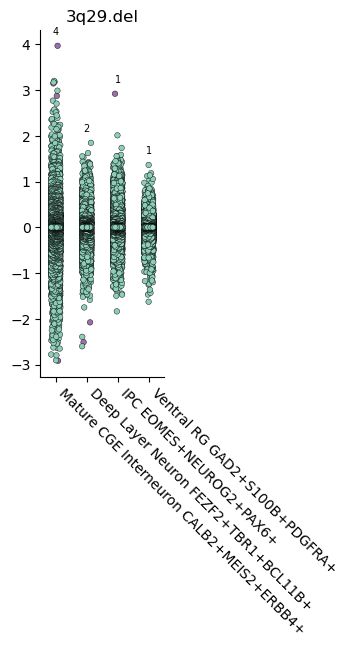

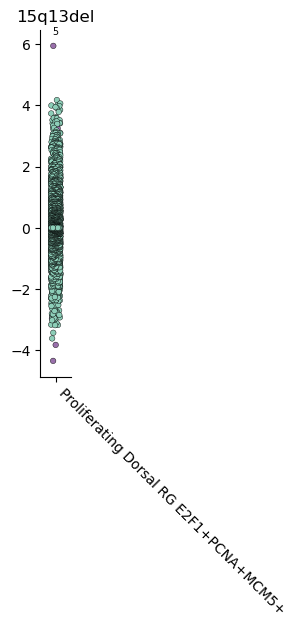

In [11]:
## Print logFC Distributions of Subtypes ##

# setup assay order and colors #
assay_order = sorted(all_subtypes["assay"].unique())

palette = dict(zip(assay_order, sns.color_palette("tab10", n_colors=len(assay_order))))

all_subtypes["significant_fdr"] = all_subtypes["significant_fdr"].astype(bool)

sig_palette = {False: "#8dceb8ff", True: "#9970ab"}

hue_order = [False, True]

for disease in all_subtypes["group"].unique():

    temp_df = all_subtypes.loc[all_subtypes["group"] == disease].copy()

    significant_celltypes = (
        temp_df.groupby("assay")["significant_fdr"]
        .any()
        .loc[lambda s: s]
        .index
    )
    temp_df = temp_df[temp_df["assay"].isin(significant_celltypes)]

    if temp_df.shape[0] == 0:
        continue

    # Count significant hits per assay
    sig_counts = (
        temp_df[temp_df["significant_fdr"]]
        .groupby("assay")
        .size()
    )

    # Order assays from most to fewest significant hits (ties alphabetically)
    present_assays = (
        sig_counts.rename("n")
        .reset_index()
        .sort_values(["n", "assay"], ascending=[False, True])
        ["assay"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(len(present_assays) * 0.4, 4.5))

    sns.stripplot(
        data=temp_df,
        x="assay",
        y="estimate",
        order=present_assays,
        hue="significant_fdr",
        hue_order=hue_order,
        palette=sig_palette,
        jitter=0.15,
        size=4,
        alpha=1,
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
    )

    # remove duplicate legends
    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_title(disease)
    ax.set_xlabel("")
    ax.set_ylabel("")

    sns.despine()
    plt.xticks(rotation=-45, ha="left")

    # Save version WITHOUT labels
    plt.savefig(
        f"/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_{disease}_subtype_stripplot_without_labels.png",
        dpi=500,
        transparent=True,
        bbox_inches="tight",
    )

    # Add number of significant hits above each assay
    yrange = temp_df["estimate"].max() - temp_df["estimate"].min()

    for x, assay in enumerate(present_assays):
        y = temp_df.loc[temp_df["assay"] == assay, "estimate"].max()
        n = sig_counts.get(assay, 0)

        ax.text(
            x,
            y + 0.03 * yrange,
            str(n),
            ha="center",
            va="bottom",
            fontsize=7,
            color="black",
        )

    # Save version WITH labels
    plt.savefig(
        f"/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_{disease}_subtype_stripplot_with_labels.png",
        dpi=500,
        transparent=True,
        bbox_inches="tight",
    )

    plt.show()

In [12]:
def run_enrichr_for_groups(gene_sets, gene_set_db='KEGG_2016'):
    
    results = []

    for (disease, celltype), genes in gene_sets.items():

        if len(genes) < 5:   # avoid tiny unstable sets
            continue

        time.sleep(1.5)  

        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gene_set_db,
            organism='hs',
            outdir=None,
            no_plot=True
        )

        df = enr.results.copy()
        df['disease'] = disease
        df['celltype'] = celltype

        results.append(df)

    return pd.concat(results, ignore_index=True)

In [13]:
gene_sets = significant_all.groupby(['group', 'assay'])['ID'].apply(list)

enrich_df = run_enrichr_for_groups(gene_sets, gene_set_db='GO_Molecular_Function_2026')

In [14]:
gene_sets_st = significant_all_st.groupby(['group', 'assay'])['ID'].apply(list)

enrich_df_st = run_enrichr_for_groups(gene_sets_st, gene_set_db='GO_Molecular_Function_2026')

/tmp/ipykernel_328585/3645674341.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))


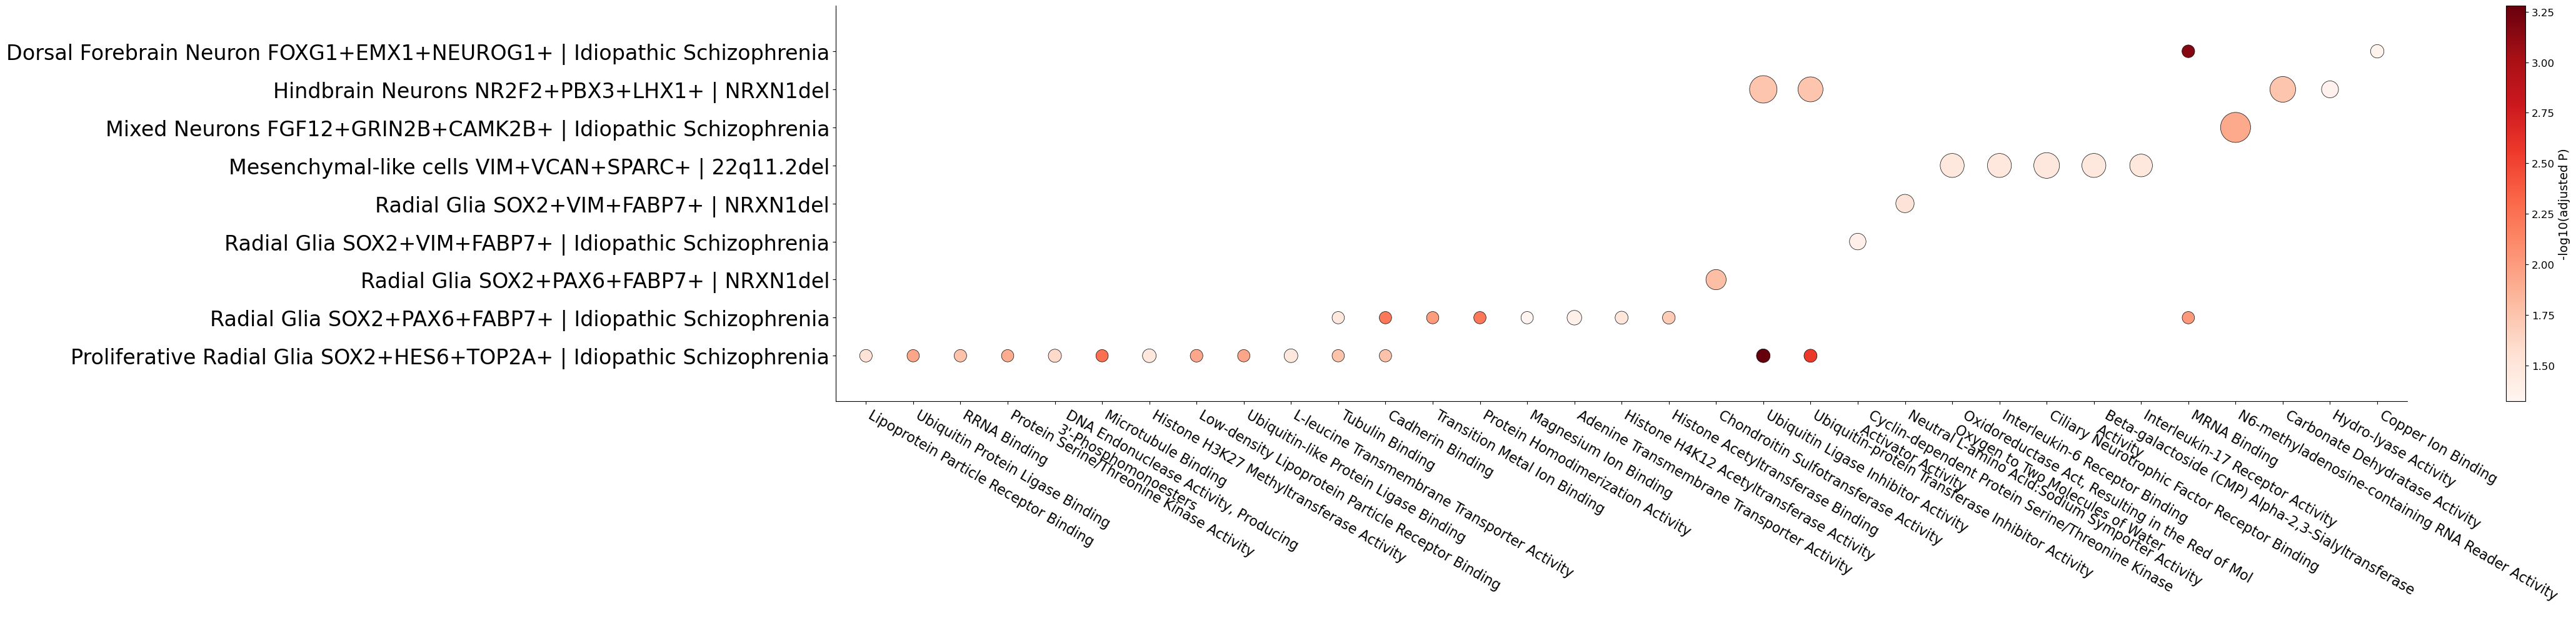

In [15]:
## Individual Signatures GO Plots ##

plot_df = (
    enrich_df
    .loc[enrich_df['Adjusted P-value'] < 0.05]
    .copy()
)

plot_df['neglogp'] = -np.log10(plot_df['Adjusted P-value'])
plot_df['group'] = plot_df['celltype'] + " | " + plot_df['disease']

# -----------------------------
# Aggregate
# -----------------------------
plot_long = (
    plot_df
    .groupby(['Term', 'group'], as_index=False)
    .agg({
        'neglogp': 'max',
        'Combined Score': 'mean',
        'Odds Ratio': 'mean'
    })
)

# -----------------------------
# Order groups
# -----------------------------
plot_long['celltype'] = plot_long['group'].str.split(r" \| ").str[0]

unique_celltypes = [
    'Proliferative Radial Glia SOX2+HES6+TOP2A+',
    'Radial Glia SOX2+PAX6+FABP7+',
    'Radial Glia SOX2+VIM+FABP7+',
    'Mesenchymal-like cells VIM+VCAN+SPARC+',
    'Mixed Neurons FGF12+GRIN2B+CAMK2B+',
    'Hindbrain Neurons NR2F2+PBX3+LHX1+',
    'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+'
]

group_order = []
for ct in unique_celltypes:
    group_order.extend(
        sorted(
            g for g in plot_long['group'].unique()
            if g.startswith(ct + " | ")
        )
    )

plot_long['group'] = pd.Categorical(
    plot_long['group'],
    categories=group_order,
    ordered=True
)

plot_long['x_pos'] = plot_long['group'].cat.codes

# -----------------------------
# Order GO terms
# -----------------------------
plot_long['Term'] = (
    plot_long['Term']
    .str.replace(r'\s*\(GO.*$', '', regex=True)
    .str.strip()
)

term_order = (
    plot_long
    .groupby('Term')
    .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))
    .sort_values()
    .index
)

plot_long['Term'] = pd.Categorical(
    plot_long['Term'],
    categories=term_order,
    ordered=True
)

# Wrapped labels (preserve ordering)
ordered_terms = plot_long['Term'].cat.categories

wrapped_labels = [
    "\n".join(textwrap.wrap(term, width=50))
    for term in ordered_terms
]

plot_long['x'] = plot_long['Term'].cat.codes

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(45, 10))

norm = mpl.colors.Normalize(
    vmin=plot_long['neglogp'].min(),
    vmax=plot_long['neglogp'].max()
)

sc = ax.scatter(
    plot_long['x'],
    plot_long['group'].cat.codes,
    c=plot_long['neglogp'],
    cmap='Reds',
    norm=norm,
    s=200 + (
        (plot_long['Odds Ratio'] - plot_long['Odds Ratio'].min()) /
        (plot_long['Odds Ratio'].max() - plot_long['Odds Ratio'].min())
    ) * 1000,
    edgecolors='black',
    linewidths=0.5
)

ax.set_xticks(range(len(ordered_terms)))
ax.set_xticklabels(
    wrapped_labels,
    rotation=-30,
    ha='left'
)

ax.set_yticks(range(len(group_order)))
ax.set_yticklabels(group_order)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=24)

for label in ax.get_yticklabels():
    label.set_fontweight('medium')

ax.margins(x=0.02, y=0.15)

sns.despine(top=True, right=True, ax=ax)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(adjusted P)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_Sig_Dot_Plot.svg",
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_328585/2582205452.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))


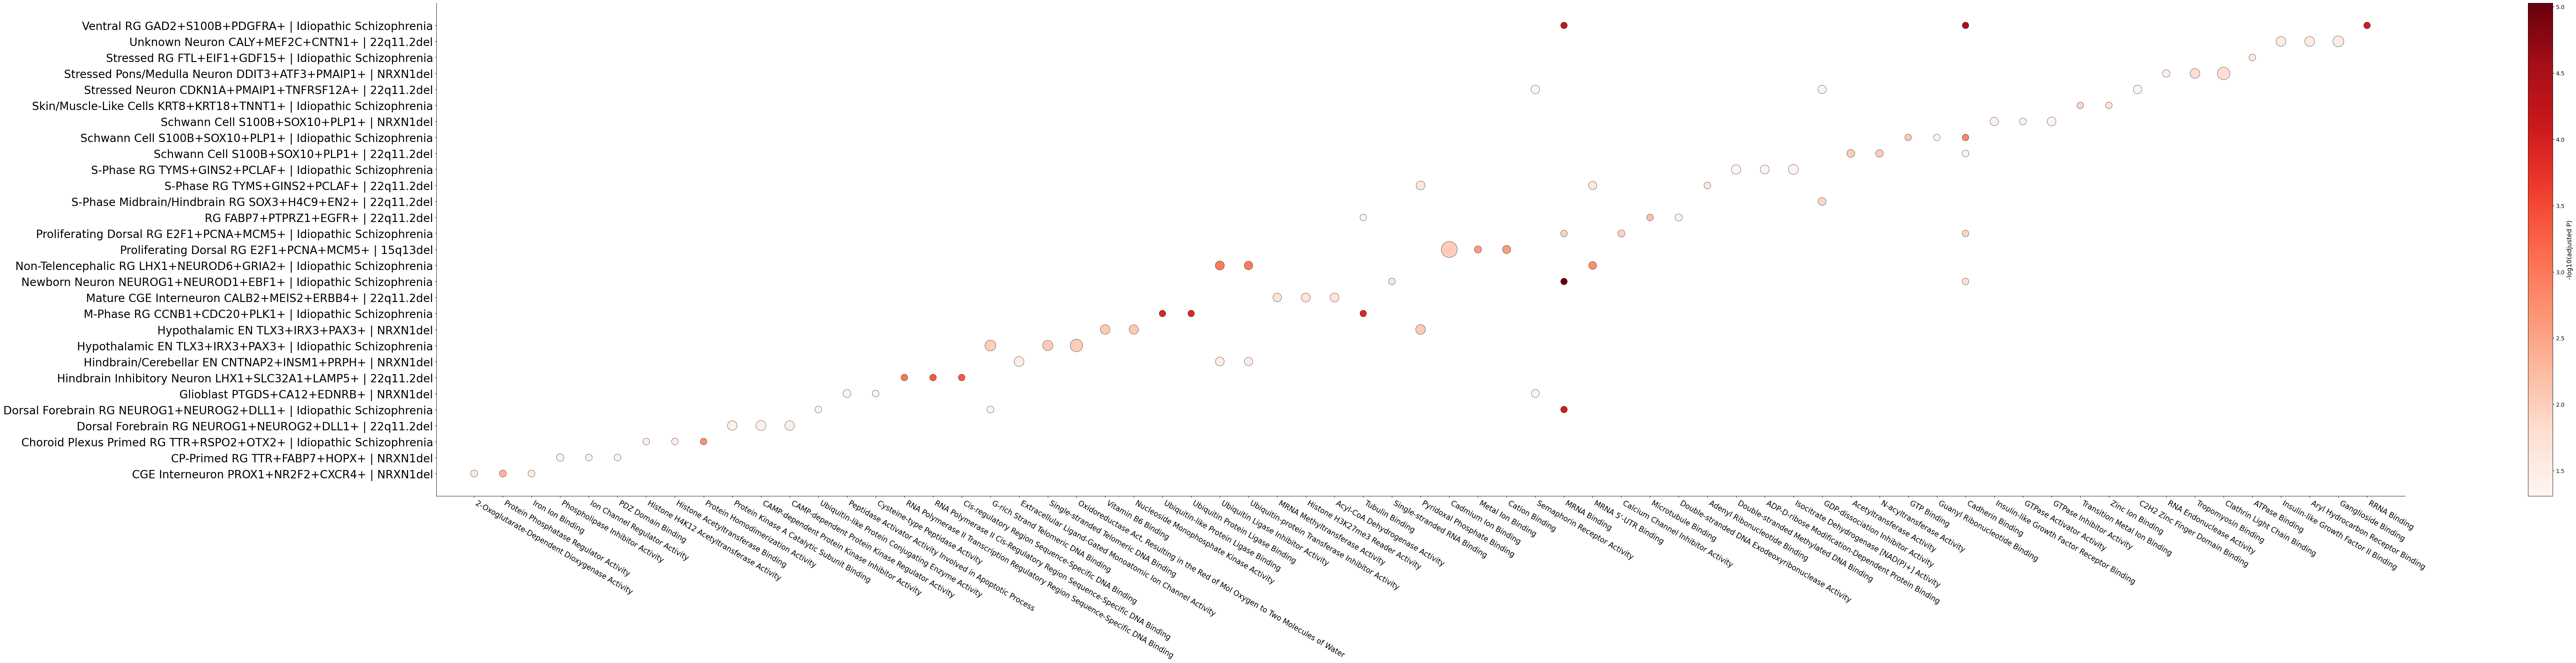

In [16]:
## Individual Signatures GO Plots ##

plot_df_st = (
    enrich_df_st
    .loc[enrich_df_st['Adjusted P-value'] < 0.05]
    .copy()
)

plot_df_st['neglogp'] = -np.log10(plot_df_st['Adjusted P-value'])
plot_df_st['group'] = plot_df_st['celltype'] + " | " + plot_df_st['disease']

# -----------------------------
# Keep top N GO terms per group
# -----------------------------
TOP_N = 3  # change to 10 if desired

plot_df_st = (
    plot_df_st
    .sort_values("Adjusted P-value")
    .groupby("group", group_keys=False)
    .head(TOP_N)
)

# -----------------------------
# Aggregate
# -----------------------------
plot_long_st = (
    plot_df_st
    .groupby(['Term', 'group'], as_index=False)
    .agg({
        'neglogp': 'max',
        'Combined Score': 'mean',
        'Odds Ratio': 'mean'
    })
)

# -----------------------------
# Order groups
# -----------------------------
plot_long_st['celltype'] = plot_long_st['group'].str.split(r" \| ").str[0]

unique_celltypes = (
    set(dge_nrxn1_st['assay'])
    .union(set(dge_22q11_st['assay']))
    .union(set(dge_idiopathic_st['assay']))
)

group_order = []
for ct in sorted(unique_celltypes):
    group_order.extend(
        sorted(
            g for g in plot_long_st['group'].unique()
            if g.startswith(ct + " | ")
        )
    )

plot_long_st['group'] = pd.Categorical(
    plot_long_st['group'],
    categories=group_order,
    ordered=True
)

plot_long_st['x_pos'] = plot_long_st['group'].cat.codes

# -----------------------------
# Clean and order GO terms
# -----------------------------
plot_long_st['Term'] = (
    plot_long_st['Term']
    .str.replace(r'\s*\(GO.*$', '', regex=True)
    .str.strip()
)

term_order = (
    plot_long_st
    .groupby('Term')
    .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))
    .sort_values()
    .index
)

plot_long_st['Term'] = pd.Categorical(
    plot_long_st['Term'],
    categories=term_order,
    ordered=True
)

ordered_terms = plot_long_st['Term'].cat.categories

wrapped_labels = [
    "\n".join(textwrap.wrap(term, width=100))
    for term in ordered_terms
]

plot_long_st['x'] = plot_long_st['Term'].cat.codes

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(max(12, len(ordered_terms) * 1.3), 20))

norm = mpl.colors.Normalize(
    vmin=plot_long_st['neglogp'].min(),
    vmax=plot_long_st['neglogp'].max()
)

# Scale point sizes
odds = plot_long_st['Odds Ratio']

if odds.max() == odds.min():
    sizes = np.repeat(500, len(odds))
else:
    sizes = 200 + (
        (odds - odds.min()) /
        (odds.max() - odds.min())
    ) * 1000

sc = ax.scatter(
    plot_long_st['x'],
    plot_long_st['group'].cat.codes,
    c=plot_long_st['neglogp'],
    cmap='Reds',
    norm=norm,
    s=sizes,
    edgecolors='black',
    linewidths=0.5
)

ax.set_xticks(range(len(ordered_terms)))
ax.set_xticklabels(
    wrapped_labels,
    rotation=-30,
    ha='left'
)

ax.set_yticks(range(len(group_order)))
ax.set_yticklabels(group_order)

ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=24)

for label in ax.get_yticklabels():
    label.set_fontweight('medium')

ax.margins(x=0.02)

sns.despine(top=True, right=True, ax=ax)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(adjusted P)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_Sig_Dot_Plot_Subtype.svg", bbox_inches="tight")

plt.show()

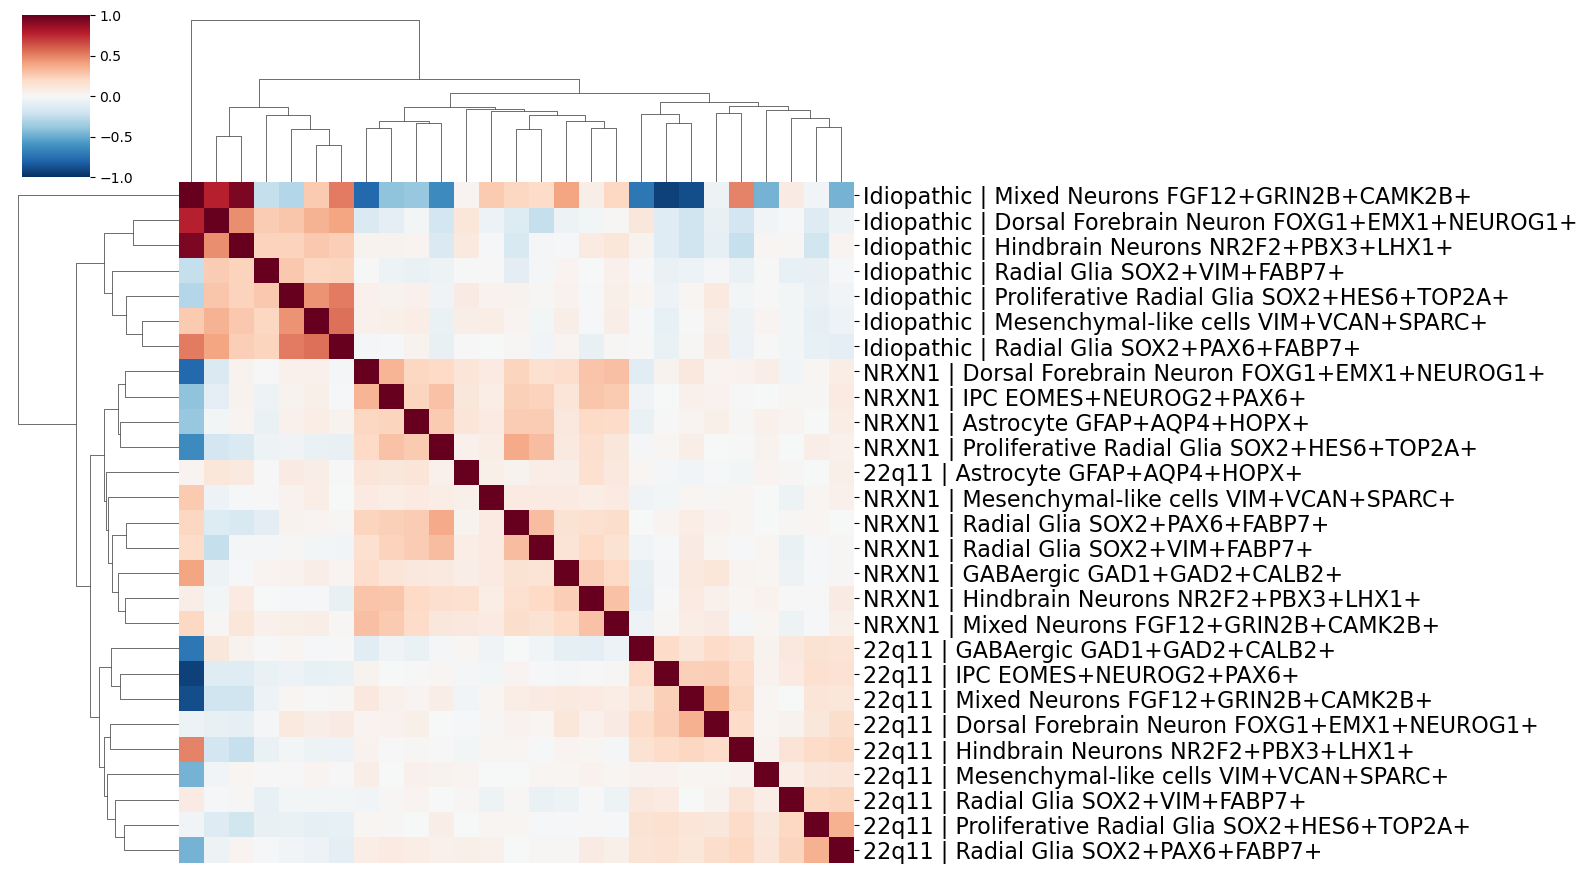

In [17]:
## Make Disease Specific Clustermap ##

idiopathic_mat = dge_idiopathic.pivot_table(index='assay', columns='ID', values='estimate')
idiopathic_mat.index = 'Idiopathic | ' + idiopathic_mat.index

x22q11_mat = dge_22q11.pivot_table(index='assay', columns='ID', values='estimate')
x22q11_mat.index = '22q11 | ' + x22q11_mat.index

nrxn1_mat = dge_nrxn1.pivot_table(index='assay', columns='ID', values='estimate')
nrxn1_mat.index = 'NRXN1 | ' + nrxn1_mat.index

all_dx_celltype = pd.concat([idiopathic_mat, x22q11_mat, nrxn1_mat], axis=0)


g = sns.clustermap(
    all_dx_celltype.T.corr(),
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    figsize=(13.5, 9),  
    xticklabels=False)

g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.tick_params(axis='y', labelsize=16)

# save figure
g.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_Sig_celltype_clustermap.svg",
          dpi=300, bbox_inches='tight')

In [18]:
corr = all_dx_celltype.T.corr()

records = []

for row in corr.index:
    for col in corr.columns:

        # avoid duplicates + self correlations
        if row >= col:
            continue

        disease1 = row.split(' | ')[0]
        disease2 = col.split(' | ')[0]

        records.append({
            'disease': disease1,
            'comparison': (
                'within'
                if disease1 == disease2
                else 'outside'
            ),
            'correlation': corr.loc[row, col]
        })

        records.append({
            'disease': disease2,
            'comparison': (
                'within'
                if disease1 == disease2
                else 'outside'
            ),
            'correlation': corr.loc[row, col]
        })

plot_df = pd.DataFrame(records)

/tmp/ipykernel_328585/806530161.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


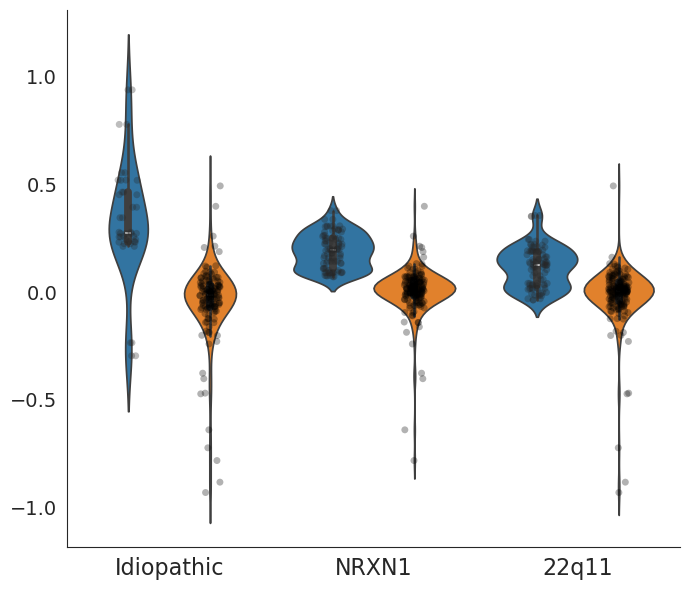

In [19]:
plt.figure(figsize=(7, 6))

sns.set_style("white")  # despine-friendly style

ax = sns.violinplot(
    data=plot_df,
    x='disease',
    y='correlation',
    hue='comparison'
)

sns.stripplot(
    data=plot_df,
    x='disease',
    y='correlation',
    hue='comparison',
    dodge=True,
    alpha=0.3,
    color='black'
)

# remove duplicate legend
ax.legend_.remove()

# despine
sns.despine()

# remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# control tick label font sizes
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=14)


plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_Sig_celltype_violins.svg", dpi=500, bbox_inches='tight')
plt.tight_layout()

In [20]:
# run t-tests within each disease
results = []

for disease in plot_df['disease'].unique():
    
    sub = plot_df[plot_df['disease'] == disease]
    
    groups = sub['comparison'].unique()
    
    if len(groups) != 2:
        continue
    
    g1 = sub[sub['comparison'] == groups[0]]['correlation']
    g2 = sub[sub['comparison'] == groups[1]]['correlation']
    
    stat, pval = ttest_ind(g1, g2, equal_var=False)  # Welch t-test
    
    results.append({
        'disease': disease,
        'group1': groups[0],
        'group2': groups[1],
        't_stat': stat,
        'p_value': pval
    })

results_df = pd.DataFrame(results)

results_df

,disease,group1,group2,t_stat,p_value
0,Idiopathic,within,outside,8.376915,2.638630e-11
1,NRXN1,outside,within,-15.153202,8.940290e-37
2,22q11,outside,within,-8.801027,2.462197e-16
